<a href="https://colab.research.google.com/github/sophia-yang424/aca_chemprop/blob/main/my_pipeline_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# 2. Clone the repo or download it
!git clone https://github.com/chemprop/chemprop_benchmark_v2.git
%cd chemprop_benchmark_v2

# 3. Clean up any corrupted files, then download and extract the data properly
!rm -rf data.tar.gz data/
!wget https://zenodo.org/records/10078142/files/data.tar.gz
!tar -xzvf data.tar.gz

Cloning into 'chemprop_benchmark_v2'...
remote: Enumerating objects: 698, done.
remote: Counting objects: 100% (238/238), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 698 (delta 161), reused 95 (delta 57), pack-reused 460 (from 1)
Receiving objects: 100% (698/698), 441.81 KiB | 8.50 MiB/s, done.
Resolving deltas: 100% (498/498), done.
/content/chemprop_benchmark_v2/chemprop_benchmark_v2
--2026-09-12 03:04:47--  https://zenodo.org/records/10078142/files/data.tar.gz
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1632346035 (1.5G) [application/octet-stream]
Saving to: ‘data.tar.gz’

data.tar.gz         100%[===================>]   1.52G  50.5MB/s    in 30s     

2026-09-12 03:05:17 (51.7 MB/s) - ‘data.tar.gz’ saved [1632346035/1632346035]

data/
data/barriers_sn2/
data/barriers_sn2/test.csv
dat

In [6]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.metrics import r2_score
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from chemprop import data, featurizers, models, nn as cp_nn
from chemprop.data.splitting import make_split_indices, split_data_by_indices

import warnings
warnings.filterwarnings('ignore')

In [5]:
%pip install -q chembl_webresource_client rdkit chemprop optuna tqdm lightning scikit-learn seaborn optuna-integration[pytorch_lightning]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.3/154.3 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.0/330.0 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 171.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd

# Load the split data directly from the CSV files
train_df = pd.read_csv('data/barriers_sn2/train.csv')
val_df = pd.read_csv('data/barriers_sn2/val.csv')
test_df = pd.read_csv('data/barriers_sn2/test.csv')

print(f"Test: {len(test_df)}, Train: {len(train_df)}, Val: {len(val_df)}")
# Expected Output: Test: 4113, Train: 32901, Val: 4113 (based on typical dataset sizes)

Test: 561, Train: 1440, Val: 360


In [11]:

import sys
from rdkit import RDLogger

# Suppress RDKit warnings
lg = RDLogger.logger()
lg.setLevel(RDLogger.ERROR)

for key in list(sys.modules.keys()):
    if key.startswith('torchvision'):
        del sys.modules[key]


# 1. Build datapoints directly from the explicitly loaded DataFrames
def build_reaction_datapoints(df, smiles_col='AAM', label_col='ea'):
    smis = df[smiles_col].tolist()
    ys = df[[label_col]].values
    # Use ReactionDatapoint since these are reaction SMILES with '>>'
    return [data.ReactionDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)]

print("Building datasets from explicit splits...")
train_data = build_reaction_datapoints(train_df)
val_data = build_reaction_datapoints(val_df)
test_data = build_reaction_datapoints(test_df)

# 2. Build Datasets & scale targets
# Use the default featurizer for ReactionDataset to properly handle reaction tuples
train_dset = data.ReactionDataset(train_data)
val_dset = data.ReactionDataset(val_data)
test_dset = data.ReactionDataset(test_data)

target_scaler = train_dset.normalize_targets()
val_dset.normalize_targets(target_scaler)
test_dset.normalize_targets(target_scaler)

# 3. Build Dataloaders
train_loader = data.build_dataloader(train_dset, num_workers=0, shuffle=True)
val_loader = data.build_dataloader(val_dset, num_workers=0, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=0, shuffle=False)
train_loader_eval = data.build_dataloader(train_dset, num_workers=0, shuffle=False)

pl.seed_everything(42, workers=True)

# Dynamically extract feature dimensions from the dataloader for Reaction graphs
sample_batch = next(iter(train_loader))
# Handle both .v/.e and .V/.E attribute naming conventions just in case
d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]
print(f"Extracted feature dimensions: d_v={d_v}, d_e={d_e}")

# 4. Define Model with extracted hyperparameters (max_lr = 0.001)
hidden_size = 300
output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

# Pass the dynamically extracted dimensions into the message passing block
mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size)
agg = cp_nn.MeanAggregation()
ffn = cp_nn.RegressionFFN(
    input_dim=hidden_size,
    output_transform=output_transform,
    dropout=0.15,
)
mpnn = models.MPNN(
    mp, agg, ffn,
    batch_norm=True,
    metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
    warmup_epochs=2,
    init_lr=1e-4,
    max_lr=0.001,
    final_lr=1e-4,
) #hyperparamters i got from the chemprop run itself when it searched

# 5. Train
early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices=1,
    enable_progress_bar=True,
    callbacks=[early_stop, checkpoint],
)

print("\nTraining custom pipeline on explicit splits...")
trainer.fit(mpnn, train_loader, val_loader)

# 6. Evaluate
best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
mpnn.load_state_dict(best_ckpt['state_dict'])
mpnn.eval()

def get_r2(loader, true_data):
    preds = trainer.predict(mpnn, loader)
    y_pred = torch.cat(preds).numpy().flatten()
    y_true = np.array([d.y[0] for d in true_data])
    return r2_score(y_true, y_pred)

r2_test = get_r2(test_loader, test_data)
r2_train = get_r2(train_loader_eval, train_data)

print(f"\n=== Custom Pipeline Final Results (barriers_sn2) ===")
print(f"Train R^2: {r2_train:.4f}")
print(f"Test R^2:  {r2_test:.4f}")


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

Building datasets from explicit splits...
Extracted feature dimensions: d_v=106, d_e=28

Training custom pipeline on explicit splits...


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  252 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 343 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 343 K                                                                                                
Total estimated model params size (MB): 1.374                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


=== Custom Pipeline Final Results (barriers_sn2) ===
Train R^2: 0.9403
Test R^2:  0.9171


on molecule ace benchmark

In [15]:
!pip install -q chemprop lightning
!pip install -q chembl_webresource_client python-Levenshtein torch-geometric
!pip install -q --no-deps MoleculeACE

KeyboardInterrupt: 

In [16]:
!pip install rdkit-pypi pandas numpy pandas chembl_webresource_client scikit-learn matplotlib tqdm python-Levenshtein

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


getting baseline for molecule ace benchmark data from moleculeAce paper using our chemprop gnn training pipeline BEFORE loss function modifcations. we used a custom pytorch training pipeline instead of chemprops built in trainer because the latter wouldnt let you touch the loss function used which we will chnage later:
below you will see a training cell that trains both for mixed aca and isolated aca (2 function callss of training fucniton we define)

In [17]:
from MoleculeACE import Data, datasets
import pandas as pd

# View all available datasets
print(datasets)  # 30 datasets from the benchmark study

# Load any dataset (e.g., CHEMBL2034_Ki - Glucocorticoid receptor)
data = Data('CHEMBL2034_Ki')

# Access the data
smiles_train = data.smiles_train
y_train = data.y_train

smiles_test = data.smiles_test
y_test = data.y_test

# Save to CSV if needed
train_df = pd.DataFrame({'smiles': smiles_train, 'y': y_train})
test_df = pd.DataFrame({'smiles': smiles_test, 'y': y_test})
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

['CHEMBL4203_Ki', 'CHEMBL2034_Ki', 'CHEMBL233_Ki', 'CHEMBL4616_EC50', 'CHEMBL287_Ki', 'CHEMBL218_EC50', 'CHEMBL264_Ki', 'CHEMBL219_Ki', 'CHEMBL2835_Ki', 'CHEMBL2147_Ki', 'CHEMBL231_Ki', 'CHEMBL3979_EC50', 'CHEMBL237_EC50', 'CHEMBL244_Ki', 'CHEMBL4792_Ki', 'CHEMBL1871_Ki', 'CHEMBL237_Ki', 'CHEMBL262_Ki', 'CHEMBL2047_EC50', 'CHEMBL239_EC50', 'CHEMBL2971_Ki', 'CHEMBL204_Ki', 'CHEMBL214_Ki', 'CHEMBL1862_Ki', 'CHEMBL234_Ki', 'CHEMBL238_Ki', 'CHEMBL235_EC50', 'CHEMBL4005_Ki', 'CHEMBL236_Ki', 'CHEMBL228_Ki']


In [18]:
from MoleculeACE import Data

data = Data('CHEMBL2034_Ki')

# Get only activity cliff compounds
cliff_indices = [i for i, cliff in enumerate(data.cliff_mols_test) if cliff == 1]
cliff_smiles = [data.smiles_test[i] for i in cliff_indices]
cliff_y = [data.y_test[i] for i in cliff_indices]

print(f"Total test: {len(data.smiles_test)}")
print(f"Cliff test: {len(cliff_smiles)}")

Total test: 152
Cliff test: 52


In [ ]:
!git clone https://github.com/molML/MoleculeACE.git

In [19]:
from sklearn.model_selection import train_test_split
from MoleculeACE import Data
import numpy as np

mac_data = Data('CHEMBL2034_Ki')

# --- 1. FULL DATA SPLITS ---
smiles_train_full = mac_data.smiles_train
y_train_full = mac_data.y_train
smiles_test_full = mac_data.smiles_test
y_test_full = mac_data.y_test

# Split train into train and val (85/15)
smiles_tr_full, smiles_val_full, y_tr_full, y_val_full = train_test_split(
    smiles_train_full, y_train_full, test_size=0.15, random_state=42
)

# --- 2. ACTIVITY CLIFF ONLY SPLITS ---
# Get indices of cliff compounds
cliff_tr_idx = [i for i, c in enumerate(mac_data.cliff_mols_train) if c == 1]
cliff_te_idx = [i for i, c in enumerate(mac_data.cliff_mols_test) if c == 1]

smiles_cliff_train = [mac_data.smiles_train[i] for i in cliff_tr_idx]
y_cliff_train = [mac_data.y_train[i] for i in cliff_tr_idx]
smiles_cliff_test = [mac_data.smiles_test[i] for i in cliff_te_idx]
y_cliff_test = [mac_data.y_test[i] for i in cliff_te_idx]

# Split cliff train into train and val (85/15)
smiles_tr_cliff, smiles_val_cliff, y_tr_cliff, y_val_cliff = train_test_split(
    smiles_cliff_train, y_cliff_train, test_size=0.15, random_state=42
)

print(f"Full Data - Train: {len(smiles_tr_full)}, Val: {len(smiles_val_full)}, Test: {len(smiles_test_full)}")
print(f"Cliff Data - Train: {len(smiles_tr_cliff)}, Val: {len(smiles_val_cliff)}, Test: {len(smiles_cliff_test)}")

Full Data - Train: 508, Val: 90, Test: 152
Cliff Data - Train: 169, Val: 30, Test: 52


In [20]:
#setting datapoints up (getting the one hot features from the smile strings for input + settingup training function)
from chemprop import data as cp_data, models, nn as cp_nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
import torch
from sklearn.metrics import r2_score

def train_chemprop_model(smiles_tr, y_tr, smiles_val, y_val, smiles_te, y_te, model_name):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    # 1. Build datapoints (MoleculeDatapoint since these are single molecules, not reactions)
    train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
    val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]
    test_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_te, y_te)]

    train_dset = cp_data.MoleculeDataset(train_pts)
    val_dset = cp_data.MoleculeDataset(val_pts)
    test_dset = cp_data.MoleculeDataset(test_pts)

    target_scaler = train_dset.normalize_targets()
    val_dset.normalize_targets(target_scaler)
    test_dset.normalize_targets(target_scaler)

    train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
    val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)
    test_loader = cp_data.build_dataloader(test_dset, num_workers=0, shuffle=False)

    pl.seed_everything(42, workers=True)

    # Extract dimensions
    sample_batch = next(iter(train_loader))
    d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
    d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

    # Define Model
    hidden_size = 300
    output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

    mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size)
    agg = cp_nn.MeanAggregation()
    ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=0.15)

    mpnn = models.MPNN(
        mp, agg, ffn, batch_norm=True,
        metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
        warmup_epochs=2, init_lr=1e-4, max_lr=0.001, final_lr=1e-4,
    )

    early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
    checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

    trainer = pl.Trainer(
        max_epochs=100, accelerator="auto", devices=1,
        enable_progress_bar=True, callbacks=[early_stop, checkpoint],
    )

    trainer.fit(mpnn, train_loader, val_loader)

    # Evaluate
    best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
    mpnn.load_state_dict(best_ckpt['state_dict'])
    mpnn.eval()

    preds = trainer.predict(mpnn, test_loader)
    y_pred = torch.cat(preds).numpy().flatten()
    r2_test = r2_score(y_te, y_pred)

    print(f"\n>>> {model_name} Final Test R^2: {r2_test:.4f} <<<")
    return mpnn, trainer, test_loader

In [21]:
# Train on FULL MoleculeACE dataset
mpnn_full, trainer_full, test_loader_full = train_chemprop_model(
    smiles_tr_full, y_tr_full,
    smiles_val_full, y_val_full,
    smiles_test_full, y_test_full,
    "Model 1: Full CHEMBL2034_Ki Data"
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Server Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_fl


Training Model 1: Full CHEMBL2034_Ki Data


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). 

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.276                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/core/saving.py:398: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.



>>> Model 1: Full CHEMBL2034_Ki Data Final Test R^2: 0.4150 <<<


In [22]:
# Train on ACTIVITY CLIFF compounds ONLY
mpnn_cliff, trainer_cliff, test_loader_cliff = train_chemprop_model(
    smiles_tr_cliff, y_tr_cliff,
    smiles_val_cliff, y_val_cliff,
    smiles_cliff_test, y_cliff_test,
    "Model 2: Activity Cliff Compounds Only"
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload


Training Model 2: Activity Cliff Compounds Only


/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.276                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/core/saving.py:398: Skipping 'metrics' parameter because it is not possible to safely dump to YAML.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.



>>> Model 2: Activity Cliff Compounds Only Final Test R^2: 0.0687 <<<


In [24]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 37.2 MB/s eta 0:00:00


In [32]:
#hyperparam search first for entire data set (mixed w ac and not ac molecules) + isolated ac molecules
import optuna
import lightning.pytorch as pl
from chemprop import data as cp_data, models, nn as cp_nn
from lightning.pytorch.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

def optimize_hyperparams_full(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=100):
    print(f"\n{'='*50}\nStarting Optuna Hyperparameter Search for: {study_name}\n{'='*50}")

    def objective(trial):
        # 1. Define hyperparameters using continuous ranges
        hidden_size = trial.suggest_int("hidden_size", 50, 300) # Range instead of fixed list
        depth = trial.suggest_int("depth", 2, 6)
        dropout = trial.suggest_float("dropout", 0.1, 0.4)
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", 1e-4, 1e-2, log=True)

        # 2. Setup Data
        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        # 3. Model Architecture (DEFINED INSIDE SO EACH TRIAL GETS A FRESH MODEL)
        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.MeanAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = models.MPNN(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
        )

        # 4. Training
        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

        trainer = pl.Trainer(
            max_epochs=30, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)
        return trainer.callback_metrics["val_loss"].item()

    # Run the hyperparameter search
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n=== Best Hyperparameters for {study_name} ===")
    print(study.best_params)
    print(f"Best Val Loss: {study.best_value}\n")
    return study.best_params

#HYPERPARAM SEARCH 1: FULL (MIXED AC + NON AC MOLECULE DATA)
best_params_full = optimize_hyperparams_full(
    smiles_tr_full, y_tr_full, smiles_val_full, y_val_full,
    study_name="Full CHEMBL2034_Ki Data", n_trials=100
)
#notice here we define the set of foud paramters as best_params_full. for the isolated, we define the found set for that data under diff name
#so when we train later on with our found paramters, these wont conflict, we have distinguished these two sets from each other

#^THE ABOVE (and below for only ac) SEARCHES WILL TRAIN YOUR MODEL BUT WONT SAVE THEM FOR SPACE SINCE IT SEARCHES + TRAINS SO MANY
#TO ACTUALLY SAVE THE MODEL WITH THE HYPERPARAMTERS, WE TRAIN AGAIN FROM SCRACTH BELOW with our found optumal hyperparamters from optuna, REPORDUCIBLE SINCE WE USE THE SAME SEED 42


[I 2026-09-14 00:55:17,480] A new study created in memory with name: no-name-e4505d20-c1d5-4f28-94bd-b71511136951
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/)


Starting Optuna Hyperparameter Search for: Full CHEMBL2034_Ki Data


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  131 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    440 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 66.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 198 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 198 K                                                                                                
Total estimated model params size (MB): 0.795                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

[I 2026-09-14 00:55:21,091] Trial 0 finished with value: 0.6222350597381592 and parameters: {'hidden_size': 220, 'depth': 5, 'dropout': 0.11602053354342429, 'init_lr': 0.0009324653799085459, 'max_lr': 0.00012122352648018195}. Best is trial 0 with value: 0.6222350597381592.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automaticall

...

[I 2026-09-14 01:04:36,385] Trial 98 finished with value: 0.5014160871505737 and parameters: {'hidden_size': 92, 'depth': 4, 'dropout': 0.11839905116444054, 'init_lr': 9.223130791826359e-05, 'max_lr': 0.0024591038042511464}. Best is trial 66 with value: 0.36889737844467163.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatical

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 30.0 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    178 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 27.3 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 57.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 57.5 K                                                                                               
Total estimated model params size (MB): 0.230                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

[I 2026-09-14 01:04:41,675] Trial 99 finished with value: 0.4396075904369354 and parameters: {'hidden_size': 89, 'depth': 4, 'dropout': 0.1387259457311917, 'init_lr': 0.00018706350256847954, 'max_lr': 0.0013498278388741}. Best is trial 66 with value: 0.36889737844467163.



=== Best Hyperparameters for Full CHEMBL2034_Ki Data ===
{'hidden_size': 142, 'depth': 3, 'dropout': 0.12320376363390537, 'init_lr': 0.00012617082228489428, 'max_lr': 0.0009899889689861036}
Best Val Loss: 0.36889737844467163



In [52]:
# HYPERPARAMETER SEARCH 2: ISOLATED (ONLY AC MOLECULE DATA)

def optimize_hyperparams_cliff(smiles_tr, y_tr, smiles_val, y_val, study_name, n_trials=100):
    print(f"\n{'='*50}\nStarting Optuna Hyperparameter Search for: {study_name}\n{'='*50}")

    def objective(trial):
        # 1. Define hyperparameters using restrictive continuous ranges for small data
        hidden_size = trial.suggest_int("hidden_size", 50, 300) # Range instead of fixed list
        depth = trial.suggest_int("depth", 2, 3)
        dropout = trial.suggest_float("dropout", 0.3, 0.7)
        init_lr = trial.suggest_float("init_lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", 1e-4, 1e-2, log=True)

        # 2. Setup Data
        train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
        val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]

        train_dset = cp_data.MoleculeDataset(train_pts)
        val_dset = cp_data.MoleculeDataset(val_pts)

        target_scaler = train_dset.normalize_targets()
        val_dset.normalize_targets(target_scaler)

        train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
        val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)

        # 3. Model Architecture
        sample_batch = next(iter(train_loader))
        d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
        d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

        mp = cp_nn.BondMessagePassing(d_v=d_v, d_e=d_e, d_h=hidden_size, depth=depth)
        agg = cp_nn.MeanAggregation()
        output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)
        ffn = cp_nn.RegressionFFN(input_dim=hidden_size, output_transform=output_transform, dropout=dropout)

        mpnn = models.MPNN(
            mp, agg, ffn, batch_norm=True,
            metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
            warmup_epochs=2, init_lr=init_lr, max_lr=max_lr, final_lr=init_lr,
        )

        # 4. Training
        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

        trainer = pl.Trainer(
            max_epochs=30, accelerator="auto", devices=1,
            enable_progress_bar=False, logger=False, callbacks=[early_stop],
        )

        trainer.fit(mpnn, train_loader, val_loader)
        return trainer.callback_metrics["val_loss"].item()

    # Run the hyperparameter search
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n=== Best Hyperparameters for {study_name} ===")
    print(study.best_params)
    print(f"Best Val Loss: {study.best_value}\n")
    return study.best_params

# Run on Activity Cliff Only Dataset
best_params_cliff = optimize_hyperparams_cliff(
    smiles_tr_cliff, y_tr_cliff, smiles_val_cliff, y_val_cliff,
    study_name="Activity Cliff Compounds Only", n_trials=100
)


[I 2026-09-14 01:34:38,800] A new study created in memory with name: no-name-7acca385-f66c-4cb1-80bf-7853ceeac5bf
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/)


Starting Optuna Hyperparameter Search for: Activity Cliff Compounds Only


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  107 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    392 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 59.4 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 167 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 167 K                                                                                                
Total estimated model params size (MB): 0.671                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

[I 2026-09-14 01:34:40,547] Trial 0 finished with value: 0.7339328527450562 and parameters: {'hidden_size': 196, 'depth': 2, 'dropout': 0.6069187293278434, 'init_lr': 0.0003372610037982668, 'max_lr': 0.007298891099153359}. Best is trial 0 with value: 0.7339328527450562.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically t

...

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.
[I 2026-09-14 01:38:24,847] Trial 98 finished with value: 0.3766036331653595 and parameters: {'hidden_size': 223, 'depth': 2, 'dropout': 0.4652856966863836, 'init_lr': 0.0004550033982980881, 'max_lr': 0.0020499588131595342}. Best is trial 44 with value: 0.2968381643295288.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experi

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  145 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    466 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 70.5 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 216 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 216 K                                                                                                
Total estimated model params size (MB): 0.866                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.
[I 2026-09-14 01:38:27,365] Trial 99 finished with value: 0.6164078116416931 and parameters: {'hidden_size': 233, 'depth': 2, 'dropout': 0.5021501424298231, 'init_lr': 0.0004418164529644175, 'max_lr': 0.0017061245968496201}. Best is trial 44 with value: 0.2968381643295288.



=== Best Hyperparameters for Activity Cliff Compounds Only ===
{'hidden_size': 235, 'depth': 2, 'dropout': 0.5055420693456245, 'init_lr': 0.0003908196647454887, 'max_lr': 0.0015799047262430666}
Best Val Loss: 0.2968381643295288



In [55]:
from chemprop import data as cp_data, models, nn as cp_nn
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
import torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

def train_tuned_chemprop_model(smiles_tr, y_tr, smiles_val, y_val, smiles_te, y_te, model_name, best_params):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    # 1. Build datapoints and datasets
    train_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_tr, y_tr)]
    val_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_val, y_val)]
    test_pts = [cp_data.MoleculeDatapoint.from_smi(s, [y]) for s, y in zip(smiles_te, y_te)]

    train_dset = cp_data.MoleculeDataset(train_pts)
    val_dset = cp_data.MoleculeDataset(val_pts)
    test_dset = cp_data.MoleculeDataset(test_pts)

    target_scaler = train_dset.normalize_targets()
    val_dset.normalize_targets(target_scaler)
    test_dset.normalize_targets(target_scaler)

    train_loader = cp_data.build_dataloader(train_dset, num_workers=0, shuffle=True)
    val_loader = cp_data.build_dataloader(val_dset, num_workers=0, shuffle=False)
    test_loader = cp_data.build_dataloader(test_dset, num_workers=0, shuffle=False)

    pl.seed_everything(42, workers=True)

    # 2. Extract dimensions
    sample_batch = next(iter(train_loader))
    d_v = sample_batch.bmg.v.shape[1] if hasattr(sample_batch.bmg, 'v') else sample_batch.bmg.V.shape[1]
    d_e = sample_batch.bmg.e.shape[1] if hasattr(sample_batch.bmg, 'e') else sample_batch.bmg.E.shape[1]

    # 3. Define Model using OPTUNA best parameters
    output_transform = cp_nn.UnscaleTransform.from_standard_scaler(target_scaler)

    mp = cp_nn.BondMessagePassing(
        d_v=d_v, d_e=d_e,
        d_h=best_params["hidden_size"],
        depth=best_params["depth"]
    )
    agg = cp_nn.MeanAggregation()
    ffn = cp_nn.RegressionFFN(
        input_dim=best_params["hidden_size"],
        output_transform=output_transform,
        dropout=best_params["dropout"]
    )

    mpnn = models.MPNN(
        mp, agg, ffn, batch_norm=True,
        metrics=[cp_nn.metrics.RMSE(), cp_nn.metrics.MAE()],
        warmup_epochs=2,
        init_lr=best_params["init_lr"],
        max_lr=best_params["max_lr"],
        final_lr=best_params["init_lr"],
    )

    # 4. Train - Stricter early stopping with min_delta
    early_stop = EarlyStopping(monitor="val_loss", patience=3, mode="min", min_delta=0.02)
    checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)

    # Use CSVLogger to track train and val losses per epoch
    logger = CSVLogger("logs", name=model_name.replace(" ", "_").replace(":", ""))

    trainer = pl.Trainer(
        max_epochs=100, accelerator="auto", devices=1,
        enable_progress_bar=False,
        logger=logger,
        callbacks=[early_stop, checkpoint],
        deterministic=True  # Force deterministic GPU operations
    )

    trainer.fit(mpnn, train_loader, val_loader)

    # 5. Evaluate best model
    best_ckpt = torch.load(checkpoint.best_model_path, map_location='cpu', weights_only=False)
    mpnn.load_state_dict(best_ckpt['state_dict'])
    mpnn.eval()

    best_epoch = best_ckpt.get('epoch', 'Unknown')
    best_val_loss = checkpoint.best_model_score.item() if checkpoint.best_model_score is not None else float('nan')
    print(f"\n[INFO] Loaded Best Model Checkpoint from Epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})")

    preds = trainer.predict(mpnn, test_loader)
    y_pred = torch.cat(preds).numpy().flatten()

    r2_test = r2_score(y_te, y_pred)
    mse_test = mean_squared_error(y_te, y_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_te, y_pred)

    print(f"\n>>> {model_name} Final Test Results <<<")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print(f"Test R^2:      {r2_test:.4f}")
    print(f"Test MSE:      {mse_test:.4f}")
    print(f"Test RMSE:     {rmse_test:.4f}")
    print(f"Test MAE:      {mae_test:.4f}")

    metrics_dict = {
        "val_loss_best": best_val_loss,
        "r2": r2_test,
        "mse": mse_test,
        "rmse": rmse_test,
        "mae": mae_test
    }

    metrics_file = f"{logger.save_dir}/{logger.name}/version_{logger.version}/metrics.csv"

    # 6. Plot Learning Curve Automatically
    try:
        df = pd.read_csv(metrics_file)
        df_agg = df.groupby("epoch").mean().reset_index()

        plt.figure(figsize=(8, 5))
        if "train_loss" in df_agg.columns:
            plt.plot(df_agg["epoch"], df_agg["train_loss"], label="Train Loss", marker="o", markersize=4)
        if "val_loss" in df_agg.columns:
            plt.plot(df_agg["epoch"], df_agg["val_loss"], label="Val Loss", marker="s", markersize=4)

        plt.title(f"Learning Curve: {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot curves: {e}")

    return mpnn, trainer, test_loader, metrics_dict, metrics_file


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload

Training tuned models...

Training Tuned Model: Full CHEMBL2034_Ki Data


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 62.9 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    284 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 43.2 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 106 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 106 K                                                                                                
Total estimated model params size (MB): 0.426                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Loaded Best Model Checkpoint from Epoch: 20 (Val Loss: 0.4165)

>>> Tuned Model: Full CHEMBL2034_Ki Data Final Test Results <<<
Best Val Loss: 0.4165
Test R^2:      0.4005
Test MSE:      0.6049
Test RMSE:     0.7777
Test MAE:      0.5725


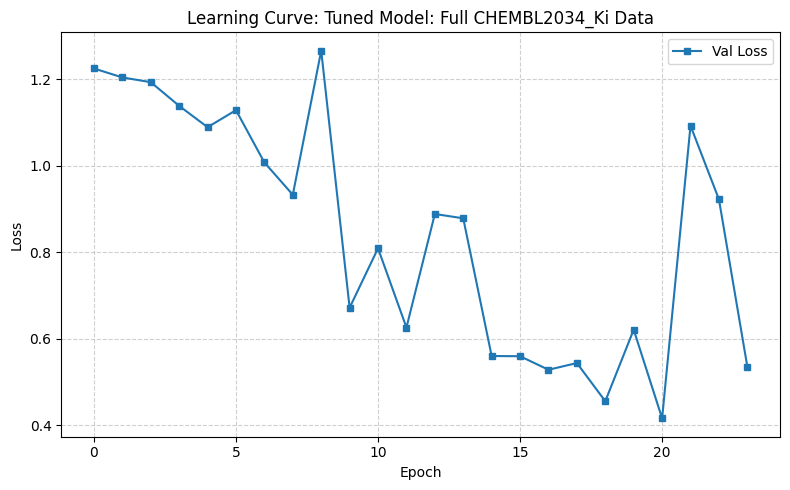

In [57]:
# --- Train Tuned Baselines ---
#train model w ideal params for mixed (aka using best_params_full)
print("Training tuned models...")
_, _, _, metrics_dict_full, metrics_full = train_tuned_chemprop_model(
    smiles_tr_full, y_tr_full, smiles_val_full, y_val_full, smiles_test_full, y_test_full,
    "Tuned Model: Full CHEMBL2034_Ki Data", best_params_full
)


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataload


Training Tuned Model: Activity Cliff Compounds Only


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  147 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    470 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 71.1 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 219 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 219 K                                                                                                
Total estimated model params size (MB): 0.878                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[INFO] Loaded Best Model Checkpoint from Epoch: 21 (Val Loss: 0.5093)

>>> Tuned Model: Activity Cliff Compounds Only Final Test Results <<<
Best Val Loss: 0.5093
Test R^2:      -0.0734
Test MSE:      0.9253
Test RMSE:     0.9619
Test MAE:      0.7769


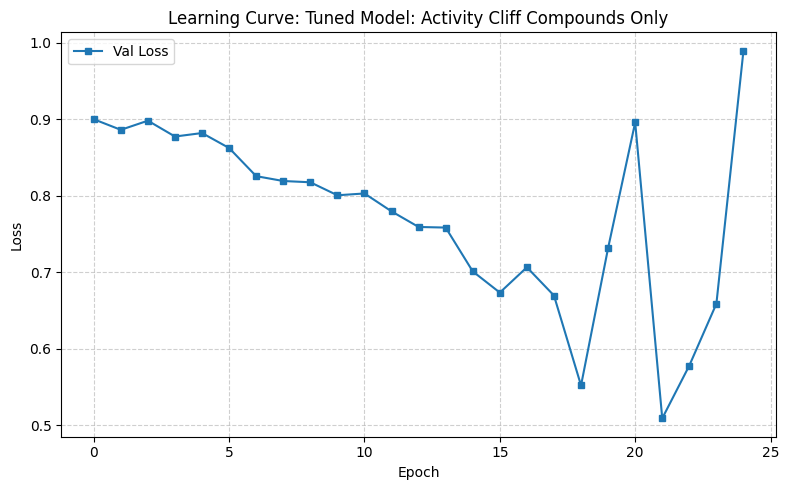

In [58]:
#train model w ideal params for isolated
_, _, _, metrics_dict_cliff, metrics_cliff = train_tuned_chemprop_model(
    smiles_tr_cliff, y_tr_cliff, smiles_val_cliff, y_val_cliff, smiles_cliff_test, y_cliff_test,
    "Tuned Model: Activity Cliff Compounds Only", best_params_cliff
)


--- Overfitting Check: Best Hyperparameters ---


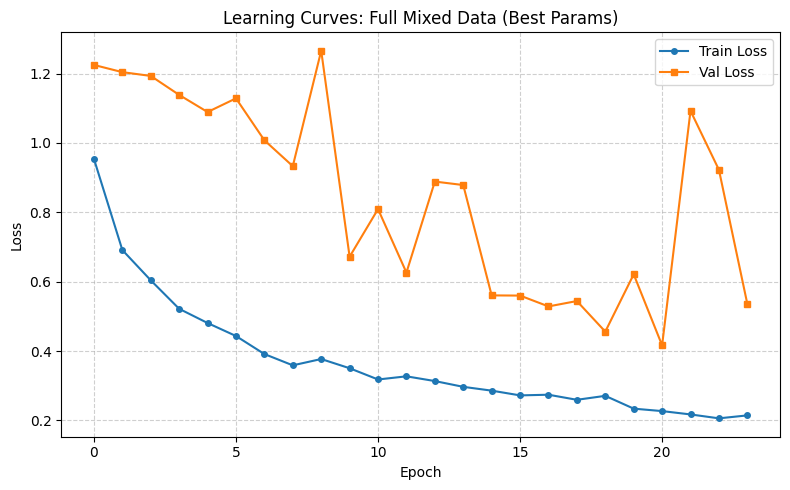

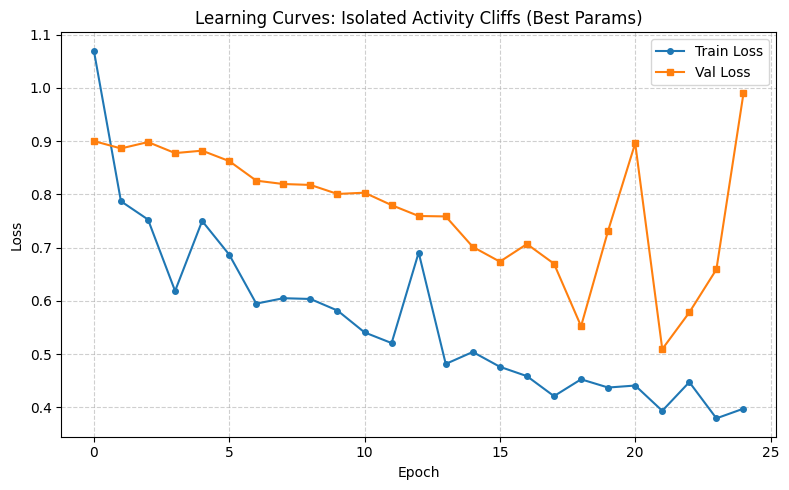

In [59]:
#plots of learning curves for final parameters we used ot teian ours (not optuna)
# plots of the models for AFTER optuna right, like the ones after we used the selected set of optimal params
import pandas as pd
import matplotlib.pyplot as plt

def plot_learning_curves(metrics_csv, title):
    try:
        df = pd.read_csv(metrics_csv)
        # Group by epoch to handle staggered train/val logging steps
        df_agg = df.groupby("epoch").mean().reset_index()

        plt.figure(figsize=(8, 5))

        # Dynamically find the train and val loss column names
        train_cols = [c for c in df_agg.columns if 'train' in c.lower() and 'loss' in c.lower()]
        val_cols = [c for c in df_agg.columns if 'val' in c.lower() and 'loss' in c.lower()]

        if train_cols:
            # Drop NaNs just in case logging steps don't perfectly align
            t_data = df_agg[['epoch', train_cols[0]]].dropna()
            plt.plot(t_data["epoch"], t_data[train_cols[0]], label="Train Loss", marker="o", markersize=4)

        if val_cols:
            v_data = df_agg[['epoch', val_cols[0]]].dropna()
            plt.plot(v_data["epoch"], v_data[val_cols[0]], label="Val Loss", marker="s", markersize=4)

        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not plot {title}: {e}")

print("--- Overfitting Check: Best Hyperparameters ---")
plot_learning_curves(metrics_full, "Learning Curves: Full Mixed Data (Best Params)")
plot_learning_curves(metrics_cliff, "Learning Curves: Isolated Activity Cliffs (Best Params)")